In [1]:
import numpy as np
import polars as pl
import seaborn as sns

from mics import qrisk3, simulation

In [2]:
# start small for a fast iteration, the scale up to 100k patients once the pipeline runs cleanly
n_patients = 1000 
random_seed = 42

In [ ]:
# Generate population
patients = simulation.generate_patients(n_patients, random_seed=random_seed)
display(patients)

Age,Sex,Ethnicity,Townsend_Score,BMI,Systolic_Blood_Pressure,SD_Systolic_Blood_Pressure,Cholesterol_HDL_Ratio,Smoking Status,Type 1 Diabetes,Type 2 Diabetes,SLE,Severe Mental Illness,CKD,Atrial_Fibrillation,Rheumatoid_Arthritis,Migraine,Erectile_Disfunction,Corticosteroids,Atypical_Antipsychotics,Treated Hypertension,Family History of CVD
i32,str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
71,"""Male""","""White""",-3.46013,31.17,137.5,2.06,2.93,"""Moderate Smoker""",0,0,0,0,0,0,0,1,1,0,0,0,1
34,"""Female""","""White""",-3.9634,26.09,127.98,5.27,3.08,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,0
80,"""Male""","""White""",-0.626348,24.88,128.2,1.51,6.34,"""Ex Smoker""",0,0,0,0,1,0,0,0,0,0,0,0,1
40,"""Male""","""White""",4.752243,25.69,113.8,2.67,4.71,"""Non-Smoker""",0,0,0,0,0,0,0,0,0,0,0,0,0
43,"""Male""","""White""",-2.289765,29.55,129.12,2.16,1.5,"""Non-Smoker""",0,0,0,0,0,0,0,0,1,0,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
73,"""Female""","""White""",2.142096,30.01,146.82,4.77,3.01,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,0,0
84,"""Female""","""White""",6.410805,27.41,129.52,4.76,4.32,"""Non-Smoker""",0,0,0,0,0,0,0,1,0,0,0,1,0
70,"""Male""","""White""",-1.597388,33.27,142.15,3.57,5.12,"""Non-Smoker""",0,0,0,0,0,1,0,0,1,0,0,0,0


# 

In [4]:
# Prevelance of Type 2 diabetes in patients over 60 should be ~ 12%, rising with BMI 
patients.filter(
    pl.col("Age") > 60
)['Type 2 Diabetes'].value_counts(sort=True, normalize=True)

Type 2 Diabetes,proportion
i64,f64
0,0.879452
1,0.120548


In [ ]:
# Type 2 diabetes prevalence should rise with age, and be higher in patients with higher BMI 
# Simple plot demonstrates this relationship - future step is to confrim via anaysis of the data
patients.group_by("Age").agg(
    (pl.col("Type 2 Diabetes")=='Type 2').mean().alias("Type 2 Diabetes")
).sort("Age").plot.line(x="Age", y="Type 2 Diabetes")

# Generate the 10 year risk for our patients

Population Statistics: shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 1000.0    │
│ null_count ┆ 0.0       │
│ mean       ┆ 12.183431 │
│ std        ┆ 13.824535 │
│ min        ┆ 0.016665  │
│ 25%        ┆ 1.341797  │
│ 50%        ┆ 6.480005  │
│ 75%        ┆ 19.156131 │
│ max        ┆ 82.483283 │
└────────────┴───────────┘
Patients risk as percentages (0-100): [2.83348232e+01 4.51922343e-01 4.76714504e+01 1.59867808e+00
 2.83227379e+00 4.76866761e-02 4.53910582e+00 1.74975853e+01
 9.56080536e-02 4.31051491e+00 1.35188272e+01 2.36022640e-02
 5.68394402e+01 2.93349266e+01 6.17473496e-01 6.24971809e+00
 8.24832832e+01 2.95278749e+00 3.88715754e+01 3.00877647e+01
 1.06835050e+01 3.32253484e+01 1.06108839e+00 3.22273891e+01
 2.53514940e+01 1.29845487e+01 3.45180137e+01 1.42903090e+01
 4.55064597e+01 4.16323133e+01 5.29812285e-02 2.14390615e+01
 8.89864081e-01 1.55577425e+00 1

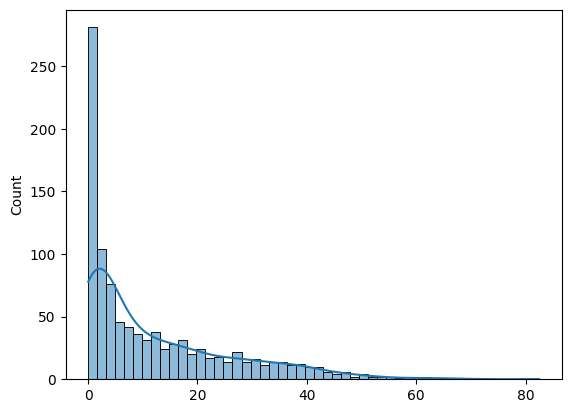

In [5]:
# This is the first step to generating the 'y' variable in our formulation. 
# Now, we have X (a matrix of risk factors), and each patient's 10 year CVD risk using QRISK3
# This returns a percentage between 0 and 100 - the the probability of a patient having a CVD event in the next 10 years

# Need to confirm that the distribution of risk looks reasonable, 
# and that the relationship between risk and 'y' (CVD event) is as expected 
patient_risk = qrisk3.calculate_qrisk3(patients)

# Perform a sanity check before plotting and generating y 
print("Population Statistics:", patient_risk.describe())
 
# Convert risk scores to numpy array for plotting, outcome sampling and further analysis
risk_pct = patient_risk.to_numpy()

# Plot distribution of risk - should be right skewed 
#TODO: need to fix the x-axis to be between 0 and 100, and add a vertical line at the mean risk
sns.histplot(risk_pct, bins=50, kde=True)

# Display risk as percentages (0-100)
print("Patients risk as percentages (0-100):", risk_pct)

# Simulate the outcomes

In [10]:
# Bernoulli sampling: 'y' is 1 if a CVD event occurs, otherwise 0 - binary outcome.
# To be used as the training target for model 1. Can the model learn the relationship between 'X' (risk factors), 
# and risk 'y' and therefore learn to predict 'y' from 'X'?

y = simulation.risk_to_event(risk_pct, random_seed=random_seed)

risk_prob = risk_pct / 100 # Recomputed for inspection

# Sanity check: 
# The event rate should be close to the mean calculated risk by QRISK3 
# The mean(y) should be close to the mean(risk_prob) - it checks that the Bernoulli sampling produces the correct ouput
print("Patients risk as predicted probabilities (0-1):", risk_prob[:10])
print("Simulated CVD events (y):", y[:10])

# Show comparisons 
print("Mean risk (%):", risk_pct.mean())
print("Event rate (%):", y.mean() * 100)
print("Event count:", y.sum())


Patients risk as predicted probabilities (0-1): [0.28334823 0.00451922 0.4767145  0.01598678 0.02832274 0.00047687
 0.04539106 0.17497585 0.00095608 0.04310515]
Simulated CVD events (y): [0 0 0 0 0 0 0 0 0 0]
Mean risk (%): 12.183431328551368
Event rate (%): 12.8
Event count: 128


In [11]:
# Test the function on a larger sample of patients - n = 10,000

# Sanity check: 
# When scaled the function should give the same event rate as the mean risk percentage from QRISK3.
# The random variation averages out and mean(y) should be very closly matched to mean(risk_prob.
# This connfirms the Bernoulli sompling is producing the correct distribution at scale. 

# Generate larger population and convert into numpy array for analysis
large_patients = simulation.generate_patients(n=10000, random_seed=42)
large_risk_pct= qrisk3.calculate_qrisk3(large_patients).to_numpy()

# Simulate outcomes 
y_large = simulation.risk_to_event(large_risk_pct, random_seed=random_seed)

# Show comparisons
print("Mean risk (%):", large_risk_pct.mean())
print("Event rate (%):", y_large.mean() * 100)
print("Event count:", y_large.sum())

Mean risk (%): 12.077980871939863
Event rate (%): 12.24
Event count: 1224


# Build the feature matrix 

In [ ]:
# Make a copy of the patients dataframe to avoid modifications to the original
matrix = patients.clone()

# One-hot encode the categorical variables 
# It turns each category into its own separate binary column (0/1)
matrix = matrix.to_dummies(columns=["Sex", "Ethnicity", "Smoking Status"])

# Convert into numpy array for model fitting
X = matrix.to_numpy()

# Sanity check:
# The shape of X should be (n_patients, n_features) - n_features is the number of risk factors after one-hot encoding
print("Column names:", matrix.columns)
print("Shape of X:", X.shape)
print("First row of X:", X[0])


Column names: ['Age', 'Sex_Female', 'Sex_Male', 'Ethnicity_Bangladeshi', 'Ethnicity_Black African', 'Ethnicity_Black Caribbean', 'Ethnicity_Chinese', 'Ethnicity_Indian', 'Ethnicity_Other Asian', 'Ethnicity_Other Ethnic Group', 'Ethnicity_Pakistani', 'Ethnicity_White', 'Townsend_Score', 'BMI', 'Systolic_Blood_Pressure', 'SD_Systolic_Blood_Pressure', 'Cholesterol_HDL_Ratio', 'Smoking Status_Ex Smoker', 'Smoking Status_Heavy Smoker', 'Smoking Status_Light Smoker', 'Smoking Status_Moderate Smoker', 'Smoking Status_Non-Smoker', 'Type 1 Diabetes', 'Type 2 Diabetes', 'SLE', 'Severe Mental Illness', 'CKD', 'Atrial_Fibrillation', 'Rheumatoid_Arthritis', 'Migraine', 'Erectile_Disfunction', 'Corticosteroids', 'Atypical_Antipsychotics', 'Treated Hypertension', 'Family History of CVD']
Shape of X: (1000, 35)
First row of X: [ 71.           0.           1.           0.           0.
   0.           0.           0.           0.           0.
   0.           1.          -3.46012957  31.17       137.5
  

# Fit a model to predict the risk

We want $y'=f(X)$ to estimate y

In [12]:
# Call fit_model function
model_1 = simulation.fit_model(X,y)

# Sanity check:
# The predicted event rate should be close to the actual event rate in 'y'; this ensures the model is well calibrated

print("Actual event rate:", y.mean())
print("Model 1 predicted event rate:", model_1.predict_proba(X)[:,1].mean()) 
# The predicted probabilities of a CVD event outcome for each patient
# It gives a two column array: the probability of the patient belonging to class 0 (no event) and class 1 (event). 
# We only care about the probability of an event - the second column; index 1.


#TODO: Inspect model coefficients to confirm that the model has learned the expected relationships between risk factors and CVD events.
# Does it make biological sense? 
# E.g. Are aga and AF positively associated with CVD risk? Is sex_female negatively associated with CVD risk? 
# Are the relationships in line with existing medical knowledge and literature on CVD risk factors?

Actual event rate: 0.128
Model 1 predicted event rate: 0.12799253112155104


# Now, let's implement the model in a new population

In [ ]:
#
X_2 = simulation.generate_patients(n_patients, random_seed=random_seed+1)
modelled_risk_2 = model_1.predict_proba(X_2)[:, 1]
on_statins = modelled_risk_2 > 0.1
X_2['on_statins'] = on_statins
risk_2 = simulation.calculate_qrisk3(X_2)
y_2 = np.random.uniform(0, 1, n_patients) < risk_2

# Now we train a second model on our second population. 

Problem: training a model $f_2(x)$ but not accounting for statins
This is the model-induced concept shift problem. 

In [ ]:
model_2 = simulation.fit_model(X_2, y_2)

# TODO: Compare the coefficients of model 1 and model 2 to see how they differ after the simulated intervention (statin prescription).
# Is there signs of coeffecient attenuation for the high-weight risk factors
# Are M2's coefficents smaller in magnitude than M1's - sign of MICS occuring (possible weaker risk-factor relationships due to the intervention)

# Generated comparative third population 

In [ ]:
# M2 should underpredict risk compared to M1 and the true event rate